[*********************100%***********************]  1 of 1 completed


Test Accuracy: 0.55


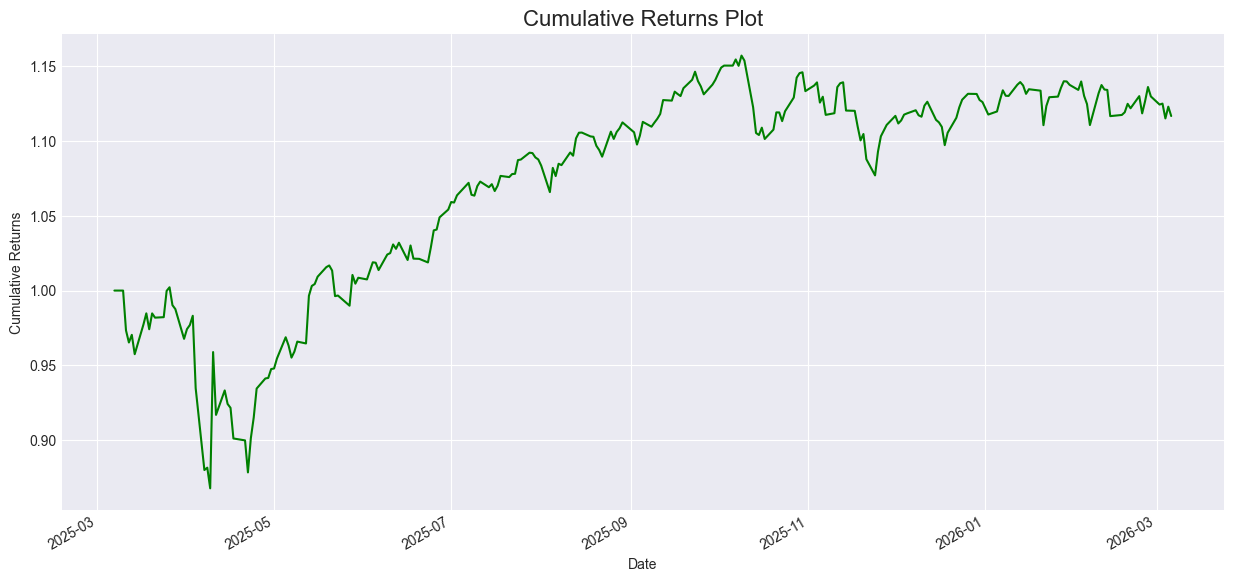

Date
2025-03-07    1.000000
2025-03-10    1.000000
2025-03-11    0.973365
2025-03-12    0.965273
2025-03-13    0.970395
                ...   
2026-03-02    1.124412
2026-03-03    1.125052
2026-03-04    1.115135
2026-03-05    1.123003
2026-03-06    1.116741
Name: cumulative_returns, Length: 251, dtype: float64

In [2]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf



spy_data = yf.download('SPY',  start='2021-03-09',end='2026-03-09')


spy_data.to_csv('spy_5years.csv')


df = pd.read_csv('spy_5years.csv',header=[0,1],index_col=0,parse_dates=True)
df.index = pd.to_datetime(df.index)
df.head()

df['Open/Close'] = df.Open / df.Close
df['High/Low'] = df.High / df.Low
X = df[['Open/Close', 'High/Low']]
X.head()

y = np.where(df['Close'].shift(-1) > df['Close'], 1, -1)
y

split_percentage = 0.8
split = int(split_percentage*len(df))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

cls = SVC().fit(X_train, y_train)

y_pred = cls.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy_test:.2f}")

df['Predicted_Signal'] = cls.predict(X)

df = df[split:]
df['Returns'] = df.Close.pct_change()
df['Strategy_Returns'] =df.Returns * df.Predicted_Signal.shift(1)
df['cumulative_returns'] =(df.Strategy_Returns + 1).cumprod().shift().fillna(1)


plt.title("Cumulative Returns Plot", fontsize=16)
plt.ylabel("Cumulative Returns")
plt.xlabel("Date")

df['cumulative_returns'].plot(figsize=(15, 7),color='g')

plt.show()
df.cumulative_returns